# Compare 4 TABR models: train/val/test + event inference

Model yang dibandingkan:
- `convat_apex_anxiety` (model dari `tabr_event_inference.ipynb`)
- `convat_apex_anxiety_qholdout_q123_q4_q5`
- `convat_apex_anxiety_qwalk_q12_q3_q4`
- `convat_apex_anxiety_qwalk_q123_q4_q5`

Compare apple-to-apple:
1. **train/val/test**: semua model dibandingkan dari best seed masing-masing
2. **event inference**: semua model dievaluasi pada **sample event yang sama** dengan **rule yang sama**


In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from scipy.special import expit
from sklearn.metrics import confusion_matrix

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TABR_ROOT = ROOT / 'third_party' / 'tabular-dl-tabr-official'
os.environ['PROJECT_DIR'] = str(TABR_ROOT)
if str(TABR_ROOT) not in sys.path:
    sys.path.append(str(TABR_ROOT))

import lib
from bin.tabr import Model
from comparasion.core.config import ComparisonConfig
from comparasion.core.roi import ROIExtractor
from features_extraction.poc import POC
from features_extraction.quadran import Quadran
from features_extraction.vektor import Vektor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EXP_ROOT = TABR_ROOT / 'exp' / 'tabr'
DATA_ROOT = TABR_ROOT / 'data'
FINAL_THRESHOLD = 0.5
TOP_K = 3
EVENT_METHODS = ['top3_mean', 'max']


In [2]:
MODEL_SPECS = [
    {
        'label': 'baseline_event_model',
        'exp_name': 'convat_apex_anxiety',
        'mode': 'baseline',
    },
    {
        'label': 'qholdout_q123_q4_q5',
        'exp_name': 'convat_apex_anxiety_qholdout_q123_q4_q5',
        'mode': 'qholdout',
    },
    {
        'label': 'qwalk_q12_q3_q4',
        'exp_name': 'convat_apex_anxiety_qwalk_q12_q3_q4',
        'mode': 'qwalkforward',
    },
    {
        'label': 'qwalk_q123_q4_q5',
        'exp_name': 'convat_apex_anxiety_qwalk_q123_q4_q5',
        'mode': 'qwalkforward',
    },
    {
        'label': 'qholdout_q123_q4_q5_alis',
        'exp_name': 'convat_apex_anxiety_qholdout_q123_q4_q5_alis',
        'mode': 'qholdout',
    },
    {
        'label': 'qwalk_q12_q3_q4',
        'exp_name': 'convat_apex_anxiety_qwalk_q12_q3_q4_alis',
        'mode': 'qwalkforward',
    },
    {
        'label': 'qwalk_q123_q4_q5',
        'exp_name': 'convat_apex_anxiety_qwalk_q123_q4_q5_alis',
        'mode': 'qwalkforward',
    },
]


def load_best_seed_report(exp_name: str) -> tuple[int, dict, Path]:
    eval_dir = EXP_ROOT / exp_name / '0-evaluation'
    rows = []
    for run_dir in sorted([x for x in eval_dir.iterdir() if x.is_dir() and x.name.isdigit()]):
        report_path = run_dir / 'report.json'
        if not report_path.exists():
            continue
        report = json.loads(report_path.read_text())
        rows.append((int(run_dir.name), report, run_dir))
    best_seed, best_report, best_run_dir = max(rows, key=lambda x: x[1]['metrics']['val']['score'])
    return best_seed, best_report, best_run_dir


def load_run_config(exp_name: str, best_seed: int, report: dict) -> dict:
    seed_toml = EXP_ROOT / exp_name / f'{best_seed}.toml'
    if seed_toml.exists():
        return lib.load_config(seed_toml)
    if 'config' in report:
        return report['config']
    tuning_toml = EXP_ROOT / exp_name / '0-tuning.toml'
    if tuning_toml.exists():
        return lib.load_config(tuning_toml)
    raise FileNotFoundError(f'No config found for {exp_name} seed {best_seed}')


def resolve_data_dir(data_path: str) -> Path:
    if data_path.startswith(':data/'):
        return DATA_ROOT / data_path.removeprefix(':data/')
    return Path(data_path)


## Compare 1 — train/val/test semua model


In [3]:
train_val_test_rows = []
model_best = {}
for spec in MODEL_SPECS:
    best_seed, report, best_run_dir = load_best_seed_report(spec['exp_name'])
    cfg = load_run_config(spec['exp_name'], best_seed, report)
    data_dir = resolve_data_dir(cfg['data']['path'])
    model_best[spec['exp_name']] = {
        'spec': spec,
        'best_seed': best_seed,
        'best_run_dir': best_run_dir,
        'config': cfg,
        'data_dir': data_dir,
    }
    for split in ['train', 'val', 'test']:
        m = report['metrics'][split]
        train_val_test_rows.append({
            'exp_name': spec['exp_name'],
            'label': spec['label'],
            'mode': spec['mode'],
            'best_seed': best_seed,
            'split': split,
            'accuracy': m['accuracy'],
            'macro_f1': m['macro avg']['f1-score'],
            'weighted_f1': m['weighted avg']['f1-score'],
            'precision_tinggi': m['1']['precision'],
            'recall_tinggi': m['1']['recall'],
            'roc_auc': m.get('roc-auc'),
            'cross_entropy': m.get('cross-entropy'),
            'data_path': cfg['data']['path'],
        })

train_val_test_df = pd.DataFrame(train_val_test_rows)
display(train_val_test_df.sort_values(['split', 'accuracy', 'macro_f1'], ascending=[True, False, False]).reset_index(drop=True))


,exp_name,label,mode,best_seed,split,accuracy,macro_f1,weighted_f1,precision_tinggi,recall_tinggi,roc_auc,cross_entropy,data_path
0,convat_apex_anxiety_qholdout_q123_q4_q5_alis,qholdout_q123_q4_q5_alis,qholdout,11,test,0.828686,0.813201,0.828862,0.869183,0.864797,0.901100,0.831797,:data/convat_apex_anxiety_qholdout_q123_q4_q5_...
1,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,5,test,0.763629,0.735308,0.760519,0.800225,0.844761,0.820196,0.636635,:data/convat_apex_anxiety_qwalk_q123_q4_q5
2,convat_apex_anxiety_qholdout_q123_q4_q5,qholdout_q123_q4_q5,qholdout,13,test,0.759989,0.729968,0.756184,0.794818,0.846839,0.816170,0.821185,:data/convat_apex_anxiety_qholdout_q123_q4_q5
3,convat_apex_anxiety,baseline_event_model,baseline,11,test,0.742826,0.728077,0.739121,0.755556,0.830827,0.820253,0.803228,:data/convat_apex_anxiety
4,convat_apex_anxiety_qwalk_q12_q3_q4,qwalk_q12_q3_q4,qwalkforward,4,test,0.714336,0.688405,0.710695,0.754572,0.803556,0.758071,0.917456,:data/convat_apex_anxiety_qwalk_q12_q3_q4
5,convat_apex_anxiety_qholdout_q123_q4_q5_alis,qholdout_q123_q4_q5_alis,qholdout,11,train,0.999108,0.999055,0.999108,0.999594,0.998962,0.999994,0.003829,:data/convat_apex_anxiety_qholdout_q123_q4_q5_...
6,convat_apex_anxiety_qholdout_q123_q4_q5,qholdout_q123_q4_q5,qholdout,13,train,0.987201,0.986401,0.987178,0.984200,0.995261,0.999271,0.041804,:data/convat_apex_anxiety_qholdout_q123_q4_q5
7,convat_apex_anxiety_qwalk_q12_q3_q4,qwalk_q12_q3_q4,qwalkforward,4,train,0.973604,0.971896,0.973498,0.967024,0.990915,0.997518,0.076374,:data/convat_apex_anxiety_qwalk_q12_q3_q4
8,convat_apex_anxiety,baseline_event_model,baseline,11,train,0.973574,0.972988,0.973549,0.971643,0.982350,0.997206,0.083300,:data/convat_apex_anxiety
9,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,5,train,0.966428,0.964224,0.966316,0.963376,0.983029,0.994998,0.105575,:data/convat_apex_anxiety_qwalk_q123_q4_q5


In [4]:
best_test_row = (
    train_val_test_df[train_val_test_df['split'] == 'test']
    .sort_values(['accuracy', 'macro_f1'], ascending=False)
    .iloc[0]
)
display(Markdown(
    f"**Best test model:** `{best_test_row['exp_name']}`  \
accuracy=`{best_test_row['accuracy']:.4f}`, macro_f1=`{best_test_row['macro_f1']:.4f}`, roc_auc=`{best_test_row['roc_auc']:.4f}`"
))

def metric_report_df(metrics: dict) -> pd.DataFrame:
    return pd.DataFrame(metrics).T[['precision', 'recall', 'f1-score', 'support']].round(6)

for spec in MODEL_SPECS:
    _, report, _ = load_best_seed_report(spec['exp_name'])
    display(Markdown(f"## `{spec['exp_name']}` (`{spec['label']}`)"))
    print('=== TRAIN CLASSIFICATION REPORT ===')
    display(metric_report_df(report['metrics']['train']))
    print('=== INTERNAL CLASSIFICATION REPORT ===')
    display(metric_report_df(report['metrics']['val']))
    print('=== EXTERNAL CLASSIFICATION REPORT ===')
    display(metric_report_df(report['metrics']['test']))
    print()


**Best test model:** `convat_apex_anxiety_qholdout_q123_q4_q5_alis`  accuracy=`0.8287`, macro_f1=`0.8132`, roc_auc=`0.9011`

## `convat_apex_anxiety` (`baseline_event_model`)

=== TRAIN CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
0,0.976205,0.961916,0.969008,14757.000000
1,0.971643,0.982350,0.976967,19603.000000
accuracy,0.973574,0.973574,0.973574,0.973574
macro avg,0.973924,0.972133,0.972988,34360.000000
weighted avg,0.973603,0.973574,0.973549,34360.000000
cross-entropy,0.083300,0.083300,0.083300,0.083300
roc-auc,0.997206,0.997206,0.997206,0.997206
score,0.973574,0.973574,0.973574,0.973574


=== INTERNAL CLASSIFICATION REPORT ===


...

,precision,recall,f1-score,support
0,0.998324,0.999343,0.998833,13707.000000
1,0.999594,0.998962,0.999278,22156.000000
accuracy,0.999108,0.999108,0.999108,0.999108
macro avg,0.998959,0.999153,0.999055,35863.000000
weighted avg,0.999108,0.999108,0.999108,35863.000000
cross-entropy,0.003829,0.003829,0.003829,0.003829
roc-auc,0.999994,0.999994,0.999994,0.999994
score,0.999108,0.999108,0.999108,0.999108


=== INTERNAL CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
0,0.784651,0.790164,0.787398,4270.000000
1,0.873016,0.869320,0.871164,7086.000000
accuracy,0.839556,0.839556,0.839556,0.839556
macro avg,0.828834,0.829742,0.829281,11356.000000
weighted avg,0.839790,0.839556,0.839667,11356.000000
cross-entropy,0.818722,0.818722,0.818722,0.818722
roc-auc,0.907984,0.907984,0.907984,0.907984
score,0.839556,0.839556,0.839556,0.839556


=== EXTERNAL CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
0,0.755960,0.762909,0.759419,3699.000000
1,0.869183,0.864797,0.866984,6738.000000
accuracy,0.828686,0.828686,0.828686,0.828686
macro avg,0.812571,0.813853,0.813201,10437.000000
weighted avg,0.829055,0.828686,0.828862,10437.000000
cross-entropy,0.831797,0.831797,0.831797,0.831797
roc-auc,0.901100,0.901100,0.901100,0.901100
score,0.828686,0.828686,0.828686,0.828686


## Setup event inference yang sama untuk semua model


In [5]:
REGIONS = {
    "mulut": list(range(48, 68)),
    "mata_kiri": list(range(17, 22)) + list(range(36, 42)),
    "mata_kanan": list(range(22, 27)) + list(range(42, 48)),
    "alis_kiri": list(range(17, 22)),
    "alis_kanan": list(range(22, 27)),
}
TARGET_SIZE = {
    "mulut": (70, 35),
    "mata_kiri": (48, 32),
    "mata_kanan": (48, 32),
    "alis_kiri": (64, 24),
    "alis_kanan": (64, 24),
}
cmp_config = ComparisonConfig(
    predictor_path=ROOT / 'preprocess-anxiety' / 'models' / 'shape_predictor_68_face_landmarks.dat',
    output_root=Path('output/apex/tmp_compare'),
    regions=REGIONS,
    target_size=TARGET_SIZE,
)
extractor = ROIExtractor(cmp_config)


def natural_sort_key(value: str):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', value)]


def to_gray(image: np.ndarray) -> np.ndarray:
    return image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def aggregate_event_probs(pred_df: pd.DataFrame, method: str, top_k: int = TOP_K) -> float:
    probs = pred_df['prob_anxiety_tinggi'].to_numpy(dtype=float)
    if len(probs) == 0:
        raise ValueError('Empty probability list')
    if method == 'mean':
        return float(np.mean(probs))
    if method == 'max':
        return float(np.max(probs))
    if method == 'median':
        return float(np.median(probs))
    if method == 'top3_mean':
        k = min(top_k, len(probs))
        return float(np.mean(np.sort(probs)[-k:]))
    raise ValueError(f'Unknown aggregation method: {method}')


def get_event_metadata(event_dir: Path) -> dict:
    parts = event_dir.parts
    true_group = 'anxiety' if 'anxiety' in parts else 'tidak' if 'tidak' in parts else None
    participant = None
    for idx, part in enumerate(parts):
        if part in {'anxiety', 'tidak'} and idx + 1 < len(parts):
            participant = parts[idx + 1]
            break
    return {'true_group': true_group, 'participant': participant}


def load_event_frames(event_dir: Path) -> tuple[list[np.ndarray], list[Path]]:
    frame_paths = sorted(
        [p for p in event_dir.iterdir() if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png'}],
        key=lambda p: natural_sort_key(p.name),
    )
    if len(frame_paths) < 2:
        raise ValueError(f'Need >= 2 frames: {event_dir}')
    frames = []
    for path in frame_paths:
        image = cv2.imread(str(path))
        if image is None:
            raise FileNotFoundError(f'Failed to read image: {path}')
        frames.append(image)
    return frames, frame_paths


def pick_distinct_participant_events(group_name: str, n: int = 15) -> list[Path]:
    root = ROOT / 'output' / 'apex' / 'dataset'
    all_dirs = sorted([p for p in root.rglob('event_*') if p.is_dir() and group_name in p.parts])
    chosen = []
    used_participants = set()
    for p in all_dirs:
        participant = get_event_metadata(p)['participant']
        if participant is None or participant in used_participants:
            continue
        used_participants.add(participant)
        chosen.append(p)
        if len(chosen) >= n:
            break
    return chosen

anxiety_events = pick_distinct_participant_events('anxiety', n=15)
tidak_events = pick_distinct_participant_events('tidak', n=15)
sample_events = anxiety_events + tidak_events

display(Markdown(f"sample_events: `{len(sample_events)}` total = `{len(anxiety_events)}` anxiety + `{len(tidak_events)}` tidak"))
pd.DataFrame({
    'event_dir': [str(x.relative_to(ROOT)) for x in sample_events],
    'true_group': [get_event_metadata(x)['true_group'] for x in sample_events],
    'participant': [get_event_metadata(x)['participant'] for x in sample_events],
}).head(10)


sample_events: `30` total = `15` anxiety + `15` tidak

,event_dir,true_group,participant
0,output/apex/dataset/after/anxiety/aaisyah_nurs...,anxiety,aaisyah_nursalsabiil_ni_patriarti_1765170495474
1,output/apex/dataset/after/anxiety/abdillah_agi...,anxiety,abdillah_agil_arbiansyah_1765270077268
2,output/apex/dataset/after/anxiety/adham_baskar...,anxiety,adham_baskara_1765260172036
3,output/apex/dataset/after/anxiety/ananda_satri...,anxiety,ananda_satria_putra_nugraha_1765170698589
4,output/apex/dataset/after/anxiety/danendra_adh...,anxiety,danendra_adhipramana_1765187441060
5,output/apex/dataset/after/anxiety/dewita_anggr...,anxiety,dewita_anggraini_1765270758137
6,output/apex/dataset/after/anxiety/dika_arie_ar...,anxiety,dika_arie_arrifky_1765267715331
7,output/apex/dataset/after/anxiety/duta_kurnia_...,anxiety,duta_kurnia_ardhani_1765255548331
8,output/apex/dataset/after/anxiety/esa_pratama_...,anxiety,esa_pratama_putri_1765175263386
9,output/apex/dataset/after/anxiety/fabian_anand...,anxiety,fabian_ananda_merdana_1765260042452


## Compare 2 — event inference rules untuk semua model


In [6]:
model_cache = {}


def load_model_bundle(exp_name: str) -> dict:
    if exp_name in model_cache:
        return model_cache[exp_name]
    info = model_best[exp_name]
    config = info['config']
    data_dir = info['data_dir']
    feature_cols = json.loads((data_dir / 'feature_cols.json').read_text())
    dataset = lib.build_dataset(**config['data']).to_torch(device)
    model = Model(
        n_num_features=dataset.n_num_features,
        n_bin_features=dataset.n_bin_features,
        cat_cardinalities=dataset.cat_cardinalities(),
        n_classes=dataset.n_classes(),
        **config['model'],
    ).to(device)
    checkpoint = lib.load_checkpoint(info['best_run_dir'])
    model.load_state_dict(checkpoint['model'])
    model.eval()
    candidate_x = {key[2:]: dataset.data[key]['train'] for key in dataset.data if key.startswith('X_')}
    candidate_y = dataset.Y['train']
    model_cache[exp_name] = {
        'model': model,
        'dataset': dataset,
        'candidate_x': candidate_x,
        'candidate_y': candidate_y,
        'feature_cols': feature_cols,
        'context_size': config['context_size'],
    }
    return model_cache[exp_name]


def extract_event_feature_rows(event_dir: Path, feature_cols: list[str]) -> pd.DataFrame:
    frames, frame_paths = load_event_frames(event_dir)
    baseline_rois = extractor.extract_rois(frames[0])
    baseline_gray = {name: to_gray(img) for name, img in baseline_rois.items()}
    rows = []
    for idx in range(1, len(frames)):
        rois = extractor.extract_rois(frames[idx])
        row = {'frame_path': str(frame_paths[idx].relative_to(ROOT)), 'frame_idx_in_event': idx}
        for comp in cmp_config.regions:
            gray = to_gray(rois[comp])
            poc = POC(baseline_gray[comp], gray, cmp_config.block_size)
            vec = Vektor(poc.getPOC(), cmp_config.block_size)
            quad = Quadran(vec.getVektor()).getQuadran()
            for block_id, block in enumerate(quad, start=1):
                row[f'{comp}_x{block_id}'] = block[1]
                row[f'{comp}_y{block_id}'] = block[2]
                row[f'{comp}_t{block_id}'] = block[3]
                row[f'{comp}_m{block_id}'] = block[4]
        rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f'No valid feature rows extracted from {event_dir}')
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise KeyError(f'Missing feature cols: {missing[:10]}')
    return pd.concat(
        [
            df[['frame_path', 'frame_idx_in_event']].reset_index(drop=True),
            df[feature_cols].reset_index(drop=True),
        ],
        axis=1,
    )


@torch.inference_mode()
def predict_feature_df(model_bundle: dict, df_features: pd.DataFrame) -> pd.DataFrame:
    feature_cols = model_bundle['feature_cols']
    x_np = df_features[feature_cols].to_numpy(dtype=np.float32)
    x_tensor = torch.as_tensor(x_np, device=device)
    rows = []
    for i in range(len(df_features)):
        x = {'num': x_tensor[i:i+1]}
        logit = model_bundle['model'](
            x_=x,
            y=None,
            candidate_x_=model_bundle['candidate_x'],
            candidate_y=model_bundle['candidate_y'],
            context_size=model_bundle['context_size'],
            is_train=False,
        ).squeeze(-1).item()
        prob = float(expit(logit))
        pred = int(prob >= FINAL_THRESHOLD)
        rows.append({
            'frame_idx_in_event': int(df_features.iloc[i]['frame_idx_in_event']),
            'frame_path': df_features.iloc[i]['frame_path'],
            'prob_anxiety_tinggi': prob,
            'pred_label': pred,
        })
    return pd.DataFrame(rows)


def infer_event_dir_for_model(exp_name: str, event_dir: Path, method: str) -> dict:
    meta = get_event_metadata(event_dir)
    model_bundle = load_model_bundle(exp_name)
    df_features = extract_event_feature_rows(event_dir, model_bundle['feature_cols'])
    pred_df = predict_feature_df(model_bundle, df_features)
    agg_prob = aggregate_event_probs(pred_df, method=method)
    agg_pred = int(agg_prob >= FINAL_THRESHOLD)
    return {
        'exp_name': exp_name,
        'event_dir': str(event_dir.relative_to(ROOT)),
        'participant': meta['participant'],
        'true_group': meta['true_group'],
        'aggregation': method,
        'agg_prob_anxiety_tinggi': agg_prob,
        'final_pred_label': agg_pred,
        'is_directionally_correct': (
            (meta['true_group'] == 'anxiety' and agg_pred == 1)
            or (meta['true_group'] == 'tidak' and agg_pred == 0)
        ) if meta['true_group'] is not None else None,
    }


def summarize_rule_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (exp_name, aggregation), part_df in df.groupby(['exp_name', 'aggregation']):
        true_label = (part_df['true_group'] == 'anxiety').astype(int).to_numpy()
        pred_label = part_df['final_pred_label'].astype(int).to_numpy()
        tn, fp, fn, tp = confusion_matrix(true_label, pred_label, labels=[0, 1]).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        accuracy = (tp + tn) / len(part_df)
        balanced_accuracy = (sensitivity + specificity) / 2
        rows.append({
            'exp_name': exp_name,
            'aggregation': aggregation,
            'n': len(part_df),
            'tp': int(tp),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'accuracy': float(accuracy),
            'balanced_accuracy': float(balanced_accuracy),
            'sensitivity_anxiety': float(sensitivity),
            'specificity_tidak': float(specificity),
        })
    return pd.DataFrame(rows)


In [7]:
event_rows = []
for spec in MODEL_SPECS:
    for event_dir in sample_events:
        for method in EVENT_METHODS:
            try:
                event_rows.append(infer_event_dir_for_model(spec['exp_name'], event_dir, method))
            except Exception as e:
                meta = get_event_metadata(event_dir)
                event_rows.append({
                    'exp_name': spec['exp_name'],
                    'event_dir': str(event_dir.relative_to(ROOT)),
                    'participant': meta['participant'],
                    'true_group': meta['true_group'],
                    'aggregation': method,
                    'error': str(e),
                })

event_compare_raw_df = pd.DataFrame(event_rows)
event_compare_eval_df = event_compare_raw_df.dropna(subset=['true_group', 'is_directionally_correct']).copy()
event_rule_summary_df = summarize_rule_metrics(event_compare_eval_df)
event_rule_summary_df = event_rule_summary_df.merge(
    pd.DataFrame(MODEL_SPECS)[['exp_name', 'label', 'mode']],
    on='exp_name',
    how='left',
)
display(event_rule_summary_df.sort_values(['aggregation', 'accuracy', 'balanced_accuracy'], ascending=[True, False, False]).reset_index(drop=True))


2026-04-10 23:57:41.316 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle
2026-04-10 23:58:28.287 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qholdout_q123_q4_q5__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle
2026-04-10 23:59:15.031 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qwalk_q12_q3_q4__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle
2026-04-10 23:59:59.889 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qwalk_q123_q4_q5__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle
2026-04-11 00:00:44.349 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qholdout_q123_q4_q5_alis__None__None__None__None__72__d1

,exp_name,aggregation,n,tp,tn,fp,fn,accuracy,balanced_accuracy,sensitivity_anxiety,specificity_tidak,label,mode
0,convat_apex_anxiety_qwalk_q12_q3_q4,max,30,12,8,7,3,0.666667,0.666667,0.800000,0.533333,qwalk_q12_q3_q4,qwalkforward
1,convat_apex_anxiety_qholdout_q123_q4_q5,max,30,11,9,6,4,0.666667,0.666667,0.733333,0.600000,qholdout_q123_q4_q5,qholdout
2,convat_apex_anxiety,max,30,15,2,13,0,0.566667,0.566667,1.000000,0.133333,baseline_event_model,baseline
3,convat_apex_anxiety_qholdout_q123_q4_q5_alis,max,30,14,2,13,1,0.533333,0.533333,0.933333,0.133333,qholdout_q123_q4_q5_alis,qholdout
4,convat_apex_anxiety_qwalk_q123_q4_q5,max,30,14,1,14,1,0.500000,0.500000,0.933333,0.066667,qwalk_q123_q4_q5,qwalkforward
5,convat_apex_anxiety_qholdout_q123_q4_q5,top3_mean,30,11,12,3,4,0.766667,0.766667,0.733333,0.800000,qholdout_q123_q4_q5,qholdout
6,convat_apex_anxiety_qholdout_q123_q4_q5_alis,top3_mean,30,14,7,8,1,0.700000,0.700000,0.933333,0.466667,qholdout_q123_q4_q5_alis,qholdout
7,convat_apex_anxiety_qwalk_q12_q3_q4,top3_mean,30,11,10,5,4,0.700000,0.700000,0.733333,0.666667,qwalk_q12_q3_q4,qwalkforward
8,convat_apex_anxiety,top3_mean,30,14,6,9,1,0.666667,0.666667,0.933333,0.400000,baseline_event_model,baseline
9,convat_apex_anxiety_qwalk_q123_q4_q5,top3_mean,30,14,1,14,1,0.500000,0.500000,0.933333,0.066667,qwalk_q123_q4_q5,qwalkforward


In [8]:
alis_exp_name = 'convat_apex_anxiety_qholdout_q123_q4_q5_alis'
alis_event_results_df = pd.DataFrame([
    infer_event_dir_for_model(alis_exp_name, event_dir, method)
    for event_dir in sample_events
    for method in ['top3_mean', 'max']
]).sort_values(['aggregation', 'participant', 'event_dir']).reset_index(drop=True)
display(alis_event_results_df)

alis_event_summary_df = summarize_rule_metrics(alis_event_results_df)
alis_event_summary_df = alis_event_summary_df.merge(
    pd.DataFrame(MODEL_SPECS)[['exp_name', 'label', 'mode']],
    on='exp_name',
    how='left',
)
display(alis_event_summary_df.sort_values(['accuracy', 'balanced_accuracy'], ascending=False).reset_index(drop=True))


,exp_name,event_dir,participant,true_group,aggregation,agg_prob_anxiety_tinggi,final_pred_label,is_directionally_correct
0,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/anxiety/aaisyah_nurs...,aaisyah_nursalsabiil_ni_patriarti_1765170495474,anxiety,max,0.993798,1,True
1,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/anxiety/abdillah_agi...,abdillah_agil_arbiansyah_1765270077268,anxiety,max,0.980241,1,True
2,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/tidak/abdul_aziz_176...,abdul_aziz_1765187125263,tidak,max,0.681885,1,False
3,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/tidak/achmad_anfasa_...,achmad_anfasa_rabbany_1765273715027,tidak,max,0.939389,1,False
4,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/anxiety/adham_baskar...,adham_baskara_1765260172036,anxiety,max,0.999826,1,True
5,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/tidak/ahmad_rifqi_he...,ahmad_rifqi_hendriansyah_1765184015048,tidak,max,0.995060,1,False
6,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/tidak/aida_rahma_fad...,aida_rahma_fadhila_1765184122948,tidak,max,0.293966,0,True
7,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/tidak/akhmad_aakhif_...,akhmad_aakhif_athallah_1765190389262,tidak,max,0.221295,0,True
8,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/anxiety/ananda_satri...,ananda_satria_putra_nugraha_1765170698589,anxiety,max,0.986615,1,True
9,convat_apex_anxiety_qholdout_q123_q4_q5_alis,output/apex/dataset/after/tidak/aryan_saputra_...,aryan_saputra_rahmad_1765167355528,tidak,max,0.664162,1,False


,exp_name,aggregation,n,tp,tn,fp,fn,accuracy,balanced_accuracy,sensitivity_anxiety,specificity_tidak,label,mode
0,convat_apex_anxiety_qholdout_q123_q4_q5_alis,top3_mean,30,14,7,8,1,0.700000,0.700000,0.933333,0.466667,qholdout_q123_q4_q5_alis,qholdout
1,convat_apex_anxiety_qholdout_q123_q4_q5_alis,max,30,14,2,13,1,0.533333,0.533333,0.933333,0.133333,qholdout_q123_q4_q5_alis,qholdout


,aggregation,exp_name,n,tp,tn,fp,fn,accuracy,balanced_accuracy,sensitivity_anxiety,specificity_tidak,label,mode
0,max,convat_apex_anxiety_qwalk_q12_q3_q4,30,12,8,7,3,0.666667,0.666667,0.800000,0.533333,qwalk_q12_q3_q4,qwalkforward
1,top3_mean,convat_apex_anxiety_qholdout_q123_q4_q5,30,11,12,3,4,0.766667,0.766667,0.733333,0.800000,qholdout_q123_q4_q5,qholdout


**Best event-inference combo:** `convat_apex_anxiety_qholdout_q123_q4_q5` + `top3_mean`  
accuracy=`0.7667`, balanced_accuracy=`0.7667`, specificity=`0.8000`

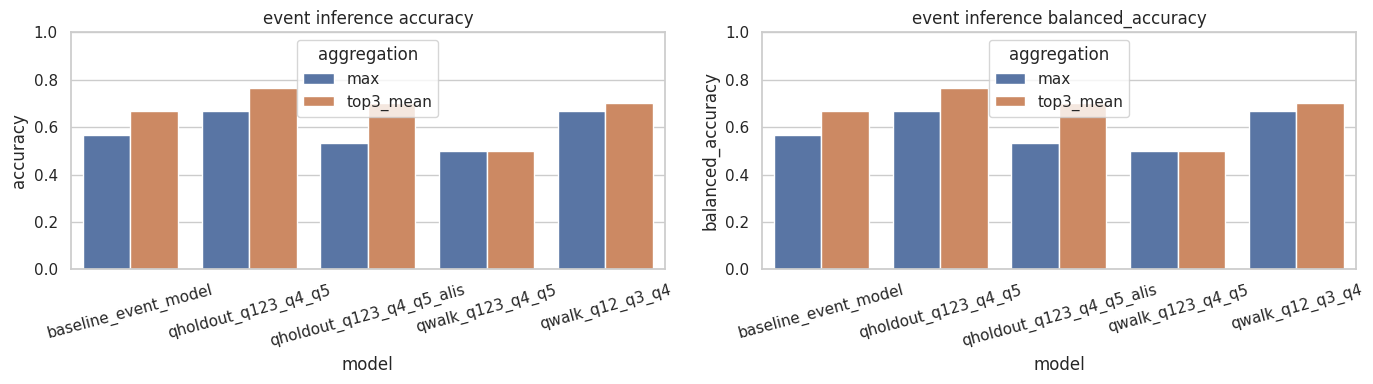

In [9]:
best_event_per_rule_df = (
    event_rule_summary_df
    .sort_values(['aggregation', 'accuracy', 'balanced_accuracy'], ascending=[True, False, False])
    .groupby('aggregation', as_index=False)
    .first()
)
display(best_event_per_rule_df)

best_event_overall = event_rule_summary_df.sort_values(['accuracy', 'balanced_accuracy'], ascending=False).iloc[0]
display(Markdown(
    f"**Best event-inference combo:** `{best_event_overall['exp_name']}` + `{best_event_overall['aggregation']}`  \naccuracy=`{best_event_overall['accuracy']:.4f}`, balanced_accuracy=`{best_event_overall['balanced_accuracy']:.4f}`, specificity=`{best_event_overall['specificity_tidak']:.4f}`"
))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=event_rule_summary_df, x='label', y='accuracy', hue='aggregation', ax=axes[0])
axes[0].set_title('event inference accuracy')
axes[0].set_xlabel('model')
axes[0].set_ylabel('accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
sns.barplot(data=event_rule_summary_df, x='label', y='balanced_accuracy', hue='aggregation', ax=axes[1])
axes[1].set_title('event inference balanced_accuracy')
axes[1].set_xlabel('model')
axes[1].set_ylabel('balanced_accuracy')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## Ringkas pemenang


In [10]:
winner_df = pd.DataFrame([
    {
        'family': 'train/val/test test-split',
        'winner_exp_name': best_test_row['exp_name'],
        'winner_label': best_test_row['label'],
        'rule_or_split': 'test',
        'accuracy': float(best_test_row['accuracy']),
        'secondary_metric': float(best_test_row['macro_f1']),
        'secondary_name': 'macro_f1',
    },
    {
        'family': 'event inference',
        'winner_exp_name': best_event_overall['exp_name'],
        'winner_label': event_rule_summary_df.loc[event_rule_summary_df['exp_name'] == best_event_overall['exp_name'], 'label'].iloc[0],
        'rule_or_split': best_event_overall['aggregation'],
        'accuracy': float(best_event_overall['accuracy']),
        'secondary_metric': float(best_event_overall['balanced_accuracy']),
        'secondary_name': 'balanced_accuracy',
    },
])
display(winner_df)


,family,winner_exp_name,winner_label,rule_or_split,accuracy,secondary_metric,secondary_name
0,train/val/test test-split,convat_apex_anxiety_qholdout_q123_q4_q5_alis,qholdout_q123_q4_q5_alis,test,0.828686,0.813201,macro_f1
1,event inference,convat_apex_anxiety_qholdout_q123_q4_q5,qholdout_q123_q4_q5,top3_mean,0.766667,0.766667,balanced_accuracy
